### Setup & imports

In [1]:
# -------------------------
#  Setup & imports
# -------------------------
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display, Markdown
import ipywidgets as widgets
import os
import json
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

# Optional: increase display width in notebook
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)


### Load data

In [2]:
# -------------------------
# 1. Load data
# -------------------------
df = pd.read_csv("/kaggle/input/understanding-career-aspirations-of-genz/Your Career Aspirations of GenZ.csv")
df_original = df.copy()
print(f"Loaded  — rows: {df.shape[0]}, columns: {df.shape[1]}")
df.head()


Loaded  — rows: 235, columns: 15


,Your Current Country.,Your Current Zip Code / Pin Code,Your Gender,Which of the below factors influence the most about your career aspirations ?,Would you definitely pursue a Higher Education / Post Graduation outside of India ? If only you have to self sponsor it.,How likely is that you will work for one employer for 3 years or more ?,Would you work for a company whose mission is not clearly defined and publicly posted.,How likely would you work for a company whose mission is misaligned with their public actions or even their product ?,How likely would you work for a company whose mission is not bringing social impact ?,What is the most preferred working environment for you.,Which of the below Employers would you work with.,Which type of learning environment that you are most likely to work in ?,Which of the below careers looks close to your Aspirational job ?,What type of Manager would you work without looking into your watch ?,Which of the following setup you would like to work ?
0,India,273005,Male,People who have changed the world for better,"Yes, I will earn and do that","This will be hard to do, but if it is the righ...",No,Will NOT work for them,4,Fully Remote with No option to visit offices,Employer who rewards learning and enables that...,"Instructor or Expert Learning Programs, Trial ...","Business Operations in any organization, Build...","Manager who explains what is expected, sets a ...","Work alone, Work with 2 to 3 people in my team..."
1,India,851129,Male,People who have changed the world for better,"No, But if someone could bare the cost I will","This will be hard to do, but if it is the righ...",No,Will NOT work for them,1,Fully Remote with Options to travel as and whe...,Employer who pushes your limits by enabling an...,"Self Paced Learning Portals, Instructor or Exp...","Business Operations in any organization, Build...","Manager who explains what is expected, sets a ...",Work with 5 to 6 people in my team
2,India,123106,Female,Social Media like LinkedIn,"Yes, I will earn and do that",Will work for 3 years or more,Yes,Will work for them,7,Hybrid Working Environment with less than 15 d...,Employer who pushes your limits by enabling an...,"Self Paced Learning Portals, Trial and error b...",Manage and drive End-to-End Projects or Produc...,"Manager who explains what is expected, sets a ...","Work with 2 to 3 people in my team, Work with ..."
3,India,834003,Male,"People from my circle, but not family members","No, But if someone could bare the cost I will","This will be hard to do, but if it is the righ...",No,Will NOT work for them,6,Hybrid Working Environment with less than 15 d...,Employer who pushes your limits by enabling an...,"Instructor or Expert Learning Programs, Trial ...","Business Operations in any organization, Manag...","Manager who explains what is expected, sets a ...",Work with 2 to 3 people in my team
4,India,301019,Female,Influencers who had successful careers,"No, But if someone could bare the cost I will",Will work for 3 years or more,No,Will NOT work for them,5,Fully Remote with Options to travel as and whe...,Employer who appreciates learning and enables ...,"Self Paced Learning Portals, Learning by obser...",Teaching in any of the institutes/online or Of...,"Manager who explains what is expected, sets a ...","Work with 2 to 3 people in my team, Work with ..."


### Quick data profile

In [3]:
# -------------------------
# 2. Quick data profile
# -------------------------
def quick_profile(df):
    display(Markdown("### Quick Data Profile"))
    display(Markdown(f"- Rows: **{df.shape[0]}**, Columns: **{df.shape[1]}**"))
    dtypes = pd.DataFrame(df.dtypes, columns=["dtype"])
    dtypes["n_missing"] = df.isna().sum()
    dtypes["n_unique"] = df.nunique()
    display(dtypes.sort_values("dtype"))
    display(Markdown("### Top 10 columns by missing values"))
    display(df.isna().sum().sort_values(ascending=False).head(10))
    
quick_profile(df)


### Quick Data Profile

- Rows: **235**, Columns: **15**

,dtype,n_missing,n_unique
Your Current Zip Code / Pin Code,int64,0,190
How likely would you work for a company whose mission is not bringing social impact ?,int64,0,10
Your Current Country.,object,0,4
Your Gender,object,0,2
Which of the below factors influence the most about your career aspirations ?,object,0,5
Would you definitely pursue a Higher Education / Post Graduation outside of India ? If only you have to self sponsor it.,object,0,3
How likely is that you will work for one employer for 3 years or more ?,object,0,3
Would you work for a company whose mission is not clearly defined and publicly posted.,object,0,2
How likely would you work for a company whose mission is misaligned with their public actions or even their product ?,object,0,2
What is the most preferred working environment for you.,object,0,6


### Top 10 columns by missing values

Your Current Country.                                                                                                       0
Your Current Zip Code / Pin Code                                                                                            0
Your Gender                                                                                                                 0
Which of the below factors influence the most about your career aspirations ?                                               0
Would you definitely pursue a Higher Education / Post Graduation outside of India ? If only you have to self sponsor it.    0
How likely is that you will work for one employer for 3 years or more ?                                                     0
Would you work for a company whose mission is not clearly defined and publicly posted.                                      0
How likely would you work for a company whose mission is misaligned with their public actions or even their product ? 

### Basic cleaning

In [4]:
# -------------------------
# 3. Basic cleaning / type coercion heuristics
# -------------------------
# Convert obvious dates, numeric-like columns
def coerce_types(df):
    df = df.copy()
    for col in df.columns:
        if df[col].dtype == object:
            # try date parse
            try:
                parsed = pd.to_datetime(df[col], errors='coerce', dayfirst=False)
                if parsed.notna().sum() / len(parsed) > 0.5:
                    df[col] = parsed
                    continue
            except Exception:
                pass
            # try numeric
            coerced = pd.to_numeric(df[col].str.replace(',', '').str.strip(), errors='coerce')
            if coerced.notna().sum() / len(coerced) > 0.8:
                df[col] = coerced
    return df

df = coerce_types(df)
print("Dtypes after coercion:")
display(df.dtypes)


Dtypes after coercion:


Your Current Country.                                                                                                       object
Your Current Zip Code / Pin Code                                                                                             int64
Your Gender                                                                                                                 object
Which of the below factors influence the most about your career aspirations ?                                               object
Would you definitely pursue a Higher Education / Post Graduation outside of India ? If only you have to self sponsor it.    object
How likely is that you will work for one employer for 3 years or more ?                                                     object
Would you work for a company whose mission is not clearly defined and publicly posted.                                      object
How likely would you work for a company whose mission is misaligned with their publ

### High-level statistical summaries

In [5]:
# -------------------------
# 4. High-level statistical summaries with interpretations
# -------------------------
def numeric_summary_and_interpretation(df):
    num = df.select_dtypes(include=[np.number]).copy()
    if num.shape[1] == 0:
        display(Markdown("**No numeric columns detected.**"))
        return
    desc = num.describe().T
    desc['skew'] = num.skew()
    desc['kurtosis'] = num.kurtosis()
    display(Markdown("### Numeric Summary"))
    display(desc)
    # Simple interpretations
    display(Markdown("### Interpretations (automated)"))
    interpretations = []
    for col in desc.index:
        row = desc.loc[col]
        note = f"**{col}**: mean={row['mean']:.3f}, median≈{num[col].median():.3f}, std={row['std']:.3f}."
        if abs(row['skew']) > 1:
            note += " Distribution is highly skewed."
        elif abs(row['skew']) > 0.5:
            note += " Distribution shows moderate skew."
        if row['std'] > 0 and row['mean'] != 0 and (row['std']/abs(row['mean']) > 1):
            note += " High relative variability."
        interpretations.append(note)
    for n in interpretations:
        display(Markdown("- " + n))

numeric_summary_and_interpretation(df)


### Numeric Summary

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
Your Current Zip Code / Pin Code,235.0,492560.970213,213622.174893,1234.0,381012.5,524412.0,607253.0,852218.0,-0.349000,-0.656934
How likely would you work for a company whose mission is not bringing social impact ?,235.0,5.272340,2.479463,1.0,3.0,5.0,7.0,10.0,-0.139145,-0.807938


### Interpretations (automated)

- **Your Current Zip Code / Pin Code**: mean=492560.970, median≈524412.000, std=213622.175.

- **How likely would you work for a company whose mission is not bringing social impact ?**: mean=5.272, median≈5.000, std=2.479.

### Categorical summary

In [6]:
# Categorical summary (top categories)
def categorical_summary_and_interpretation(df, top_k=10):
    cat = df.select_dtypes(include=['object', 'category']).copy()
    if cat.shape[1] == 0:
        display(Markdown("**No categorical/text columns detected.**"))
        return
    display(Markdown("### Categorical Summary (top categories)"))
    for col in cat.columns:
        vc = df[col].fillna("<<MISSING>>").value_counts().head(top_k)
        display(Markdown(f"**{col}** — unique: {df[col].nunique()}"))
        display(vc)
        # Quick interpretation
        top_pct = vc.iloc[0] / len(df)
        display(Markdown(f"- Top category '{vc.index[0]}' is {top_pct:.1%} of rows."))
        
categorical_summary_and_interpretation(df)


### Categorical Summary (top categories)

**Your Current Country.** — unique: 4

Your Current Country.
India                       231
Germany                       2
United Arab Emirates          1
United States of America      1
Name: count, dtype: int64

- Top category 'India' is 98.3% of rows.

**Your Gender** — unique: 2

...

What type of Manager would you work without looking into your watch ?
Manager who explains what is expected, sets a goal and helps achieve it    129
Manager who clearly describes what she/he needs                             45
Manager who sets goal and helps me achieve it                               37
Manager who sets targets and expects me to achieve it                       21
Manager who sets unrealistic targets                                         3
Name: count, dtype: int64

- Top category 'Manager who explains what is expected, sets a goal and helps achieve it' is 54.9% of rows.

**Which of the following setup you would like to work ?** — unique: 20

Which of the following setup you would like to work ?
Work with 5 to 6 people in my team                                                                                                                                           63
Work with 2 to 3 people in my team                                                                                                                                           55
Work with more than 10 people in my team                                                                                                                                     26
Work alone                                                                                                                                                                   16
Work with 7 to 10 or more people in my team                                                                                                                                  15
Work alone, Work with 2 to 3 people in my team                    

- Top category 'Work with 5 to 6 people in my team' is 26.8% of rows.

### Correlation & heatmap

In [7]:
# -------------------------
# 5. Correlation & heatmap for numeric features
# -------------------------
def show_correlation_heatmap(df, annot=True, figsize=(900,700)):
    num = df.select_dtypes(include=[np.number])
    if num.shape[1] < 2:
        display(Markdown("**Not enough numeric columns for correlation heatmap.**"))
        return
    corr = num.corr()
    fig = px.imshow(corr, text_auto=True, aspect="auto", title="Numeric Feature Correlation (Pearson)")
    fig.update_layout(height=600, width=800)
    fig.show()
    return corr

corr = show_correlation_heatmap(df)


### Interactive dashboard components

In [8]:
# -------------------------
# 6. Interactive dashboard components
#    - a) widget-driven filter
#    - b) interactive plotly charts
# -------------------------
# Build generic widget controls for the two most common column types
cols = list(df.columns)

# helpers to choose default columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Dropdown widgets
x_dropdown = widgets.Dropdown(options=numeric_cols + categorical_cols, value=(numeric_cols[0] if numeric_cols else categorical_cols[0]), description='X:')
y_dropdown = widgets.Dropdown(options=numeric_cols + categorical_cols, value=(numeric_cols[1] if len(numeric_cols)>1 else (numeric_cols[0] if numeric_cols else categorical_cols[0])), description='Y:')
color_dropdown = widgets.Dropdown(options=[None] + categorical_cols, value=(categorical_cols[0] if categorical_cols else None), description='Color:')
filter_col_dropdown = widgets.Dropdown(options=[None] + categorical_cols, value=(categorical_cols[0] if categorical_cols else None), description='FilterCol:')
filter_value_dropdown = widgets.Dropdown(options=['All'], description='FilterVal:')

# update filter values when filter column changes
def update_filter_values(*args):
    col = filter_col_dropdown.value
    if col is None:
        filter_value_dropdown.options = ['All']
    else:
        vals = df[col].dropna().unique().tolist()
        # if many unique values, show top frequent
        if len(vals) > 200:
            vals = df[col].value_counts().head(100).index.tolist()
        vals = ['All'] + vals
        filter_value_dropdown.options = vals

filter_col_dropdown.observe(update_filter_values, names='value')
update_filter_values()


### Plotting function to react to widget state


In [9]:
# Plotting function to react to widget state
def interactive_plot(x, y, color=None, filter_col=None, filter_val='All'):
    d = df.copy()
    if filter_col and filter_val != 'All':
        d = d[d[filter_col] == filter_val]
    # choose plot type heuristics
    x_is_num = pd.api.types.is_numeric_dtype(d[x])
    y_is_num = pd.api.types.is_numeric_dtype(d[y])
    if x_is_num and y_is_num:
        fig = px.scatter(d, x=x, y=y, color=color, title=f"Scatter: {y} vs {x}")
        # add trendline
        try:
            fig.add_traces(px.line(x=sorted(d[x].dropna()), y=np.poly1d(np.polyfit(d[x].dropna(), d[y].dropna(), 1))(sorted(d[x].dropna()))).data)
        except Exception:
            pass
    elif (not x_is_num) and y_is_num:
        # boxplot / violin of y by x
        fig = px.box(d, x=x, y=y, color=color, title=f"Distribution of {y} by {x}")
    elif x_is_num and (not y_is_num):
        fig = px.histogram(d, x=x, color=y, marginal="box", title=f"Histogram of {x} colored by {y}")
    else:
        # both categorical -> heatmap of counts
        ct = pd.crosstab(d[x].fillna('<<MISSING>>'), d[y].fillna('<<MISSING>>'))
        fig = px.imshow(ct, text_auto=True, title=f"Counts: {x} vs {y}")
    fig.update_layout(height=600, width=900)
    fig.show()

# interactive output
out = widgets.interactive_output(interactive_plot, {'x': x_dropdown, 'y': y_dropdown, 'color': color_dropdown, 'filter_col': filter_col_dropdown, 'filter_val': filter_value_dropdown})

controls = widgets.VBox([widgets.HBox([x_dropdown, y_dropdown, color_dropdown]), widgets.HBox([filter_col_dropdown, filter_value_dropdown])])
display(Markdown("## Interactive Charts"))
display(controls, out)


## Interactive Charts

Output()

### Key metrics / KPI cards (displayed as simple values)

In [10]:
# -------------------------
# 7. Key metrics / KPI cards (displayed as simple values)
# -------------------------
def kpi_cards(df):
    display(Markdown("## Key metrics / KPIs"))
    n_rows = len(df)
    n_missing_total = df.isna().sum().sum()
    n_unique_cols = df.nunique().mean()
    # If there is a 'salary' or 'expected_salary' like column, compute median
    salary_cols = [c for c in df.columns if 'salary' in c.lower() or 'income' in c.lower() or 'pay' in c.lower()]
    md_salary = None
    if salary_cols:
        md_salary = df[salary_cols[0]].median()
    # Top categorical columns by dominance
    cat = df.select_dtypes(include=['object', 'category']).columns
    dominance = {}
    for c in cat:
        top_pct = df[c].fillna('<<MISSING>>').value_counts(normalize=True).iloc[0]
        dominance[c] = top_pct
    top_dom = sorted(dominance.items(), key=lambda x: x[1], reverse=True)[:3]
    # render
    display(Markdown(f"- Rows: **{n_rows}**"))
    display(Markdown(f"- Total missing cells: **{n_missing_total}**"))
    display(Markdown(f"- Average unique values per column: **{n_unique_cols:.1f}**"))
    if md_salary is not None and not np.isnan(md_salary):
        display(Markdown(f"- Median {salary_cols[0]}: **{md_salary:.2f}**"))
    if top_dom:
        display(Markdown("- Top dominant categories:"))
        for c, pct in top_dom:
            display(Markdown(f"  - **{c}**: top category covers **{pct:.1%}** of rows"))

kpi_cards(df)


## Key metrics / KPIs

- Rows: **235**

- Total missing cells: **0**

- Average unique values per column: **23.1**

- Top dominant categories:

  - **Your Current Country.**: top category covers **98.3%** of rows

  - **How likely would you work for a company whose mission is misaligned with their public actions or even their product ?**: top category covers **67.2%** of rows

  - **Would you work for a company whose mission is not clearly defined and publicly posted.**: top category covers **66.8%** of rows

### Automated insights & recommendations (very simple rule-based)

In [11]:
# -------------------------
# 8. Automated insights & recommendations (very simple rule-based)
# -------------------------
def auto_insights(df, corr_threshold=0.6):
    display(Markdown("## Automated Insights"))
    insights = []
    # 1. High missingness
    missing_pct = (df.isna().mean()).sort_values(ascending=False)
    high_missing = missing_pct[missing_pct > 0.2]
    if len(high_missing) > 0:
        insights.append("Columns with >20% missing: " + ", ".join([f"{c} ({missing_pct[c]:.0%})" for c in high_missing.index[:10]]))
    # 2. Strong correlations
    num = df.select_dtypes(include=[np.number])
    strong_pairs = []
    if num.shape[1] >= 2:
        corrmat = num.corr().abs()
        for i, col in enumerate(corrmat.columns):
            for j, col2 in enumerate(corrmat.columns):
                if j <= i:
                    continue
                v = corrmat.iloc[i, j]
                if v >= corr_threshold:
                    strong_pairs.append((col, col2, v))
    if strong_pairs:
        strong_pairs = sorted(strong_pairs, key=lambda x: -x[2])[:10]
        insights.append("Strong numeric correlations (|r| >= {:.2f}): ".format(corr_threshold) + "; ".join([f"{a}↔{b} (r={r:.2f})" for a,b,r in strong_pairs]))
    # 3. Dominant categories
    cat = df.select_dtypes(include=['object', 'category'])
    dom = []
    for c in cat.columns:
        top_pct = df[c].value_counts(normalize=True, dropna=False).iloc[0]
        if top_pct > 0.5:
            dom.append((c, top_pct))
    if dom:
        insights.append("Columns heavily dominated by one value (>50%): " + ", ".join([f"{c} ({p:.0%})" for c,p in dom]))
    # 4. Skewed numerics
    skewed = []
    for c in num.columns:
        s = df[c].skew()
        if abs(s) > 1:
            skewed.append((c, s))
    if skewed:
        insights.append("Highly skewed numeric columns: " + ", ".join([f"{c} (skew={s:.2f})" for c,s in skewed[:10]]))
    # Print insights
    if len(insights) == 0:
        display(Markdown("- No automated insights found with current thresholds. Try lowering thresholds."))
    else:
        for i,ins in enumerate(insights):
            display(Markdown(f"{i+1}. {ins}"))
    # Recommendations based on insights
    display(Markdown("### Recommendations (automated)"))
    recs = []
    if len(high_missing) > 0:
        recs.append("Consider dropping or imputing high-missing columns. If missingness is informative, create a 'missing' indicator feature.")
    if strong_pairs:
        recs.append("Strongly correlated numeric pairs may indicate redundancy — consider dimensionality reduction (PCA) or dropping one column.")
    if dom:
        recs.append("Highly-dominant categorical columns might have low predictive value — consider grouping rare classes or dropping column.")
    if skewed:
        recs.append("Skewed numeric distributions may benefit from log or Box-Cox transforms before modeling.")
    if not recs:
        recs.append("Data looks generally clean for exploratory work; proceed to feature engineering and modeling.")
    for r in recs:
        display(Markdown("- " + r))

auto_insights(df)


## Automated Insights

1. Columns heavily dominated by one value (>50%): Your Current Country. (98%), Your Gender (66%), How likely is that you will work for one employer for 3 years or more ? (59%), Would you work for a company whose mission is not clearly defined and publicly posted. (67%), How likely would you work for a company whose mission is misaligned with their public actions or even their product ? (67%), What type of Manager would you work without looking into your watch ? (55%)

### Recommendations (automated)

- Highly-dominant categorical columns might have low predictive value — consider grouping rare classes or dropping column.

### static visualizations (save-to-file too)

In [12]:
# -------------------------
# 9. Example static visualizations (save-to-file too)
# -------------------------
# Distribution grid for top numeric columns
num_cols = numeric_cols[:6]  # first 6 numeric columns
if len(num_cols) > 0:
    fig = make_subplots(rows=len(num_cols), cols=1, shared_xaxes=False, subplot_titles=num_cols, vertical_spacing=0.06)
    for i, col in enumerate(num_cols, start=1):
        trace = go.Histogram(x=df[col].dropna(), nbinsx=30, name=col, opacity=0.9)
        fig.add_trace(trace, row=i, col=1)
    fig.update_layout(height=300*len(num_cols), title_text="Numeric distributions")
    fig.show()

# Top categorical counts for first 4 categorical columns
for c in categorical_cols[:4]:
    vc = df[c].value_counts().head(20)
    fig = px.bar(x=vc.index.astype(str), y=vc.values, title=f"Top counts: {c}")
    fig.update_layout(xaxis_title=c, yaxis_title="count", height=450, width=900)
    fig.show()


### Export an interactive HTML report (optional)

In [13]:
# -------------------------
# 10. Export an interactive HTML report (optional)
# -------------------------
# This will save a minimal HTML report with a few key charts (Plotly) and JSON summaries.
# You can run this cell to produce a downloadable file.
def export_html_report(df, out_path="/kaggle/working/eda_report.html"):
    now = datetime.utcnow().strftime("%Y%m%dT%H%M%SZ")
    title = f"EDA Report - {now}"
    # build simple html sections
    # 1) summary json
    summary = {
        "rows": len(df),
        "columns": df.shape[1],
        "missing_by_col": df.isna().sum().to_dict(),
        "num_summary": df.select_dtypes(include=[np.number]).describe().to_dict()
    }
    # create a few plotly figs and embed
    figs = []
    # correlation heatmap
    num = df.select_dtypes(include=[np.number])
    if num.shape[1] >= 2:
        figs.append(px.imshow(num.corr(), text_auto=True, title="Correlation Heatmap"))
    # top categorical bar for first categorical col
    catcols = df.select_dtypes(include=['object', 'category']).columns
    if len(catcols) > 0:
        vc = df[catcols[0]].value_counts().head(20)
        figs.append(px.bar(x=vc.index.astype(str), y=vc.values, title=f"Top counts: {catcols[0]}"))
    # assemble html
    from plotly.offline import plot
    parts = [f"<h1>{title}</h1>"]
    parts.append("<h2>Summary</h2>")
    parts.append(f"<pre>{json.dumps(summary, indent=2)}</pre>")
    for f in figs:
        div = plot(f, output_type='div', include_plotlyjs='cdn')
        parts.append(div)
    html = "<html><head><meta charset='utf-8'></head><body>" + "\n".join(parts) + "</body></html>"
    with open(out_path, "w", encoding="utf-8") as fh:
        fh.write(html)
    print(f"Saved HTML report to {out_path}")
    return out_path

# Uncomment to export
# report_path = export_html_report(df)
# print("Report saved to:", report_path)


In [14]:
# -------------------------
# 11. save cleaned dataset for modeling
# -------------------------
clean_path = "/kaggle/working/cleaned_genz_career_aspirations.csv"
df.to_csv(clean_path, index=False)
print("Cleaned data saved to", clean_path)


Cleaned data saved to /kaggle/working/cleaned_genz_career_aspirations.csv



---

### Quick notes & suggestions
- If your dataset is large (>200k rows) consider sampling in the interactive widgets to keep notebook responsive (e.g., `d = df.sample(50000)` inside the plotting function).
- If you want a full single-page served dashboard (Dash/Streamlit), that needs a long-running web server and is not the default way Kaggle Notebooks are used — the code above gives in-notebook interactivity suitable for Kaggle.
- If you want, I can:
  - convert this into a ready-to-run `.ipynb` file and provide a download link,
  - or add more targeted charts if you tell me the top 3 columns of interest (e.g., `career_interest`, `expected_salary`, `preferred_skills`).
  
Want me to convert this into a downloadable notebook file (ipynb) right now? If yes I’ll generate it and give you the download path.


### Classification models

ORIGINAL CLASS DISTRIBUTION
Which of the below careers looks close to your Aspirational job ?
Business Operations in any organization, Design and Develop amazing software, Become a content Creator in some platform                           1
Design and Creative strategy in any company, Design and Develop amazing software, Work as a freelancer and do my thing my way                     1
Build and develop a Team, Design and Develop amazing software, Become a content Creator in some platform                                          1
Teaching in any of the institutes/online or Offline, Business Operations in any organization, Work as a freelancer and do my thing my way         1
Design and Creative strategy in any company, Manage and drive End-to-End Projects or Products, Work in a BPO setup for some well known client     1
                                                                                                                                                 ..
Design and Creativ

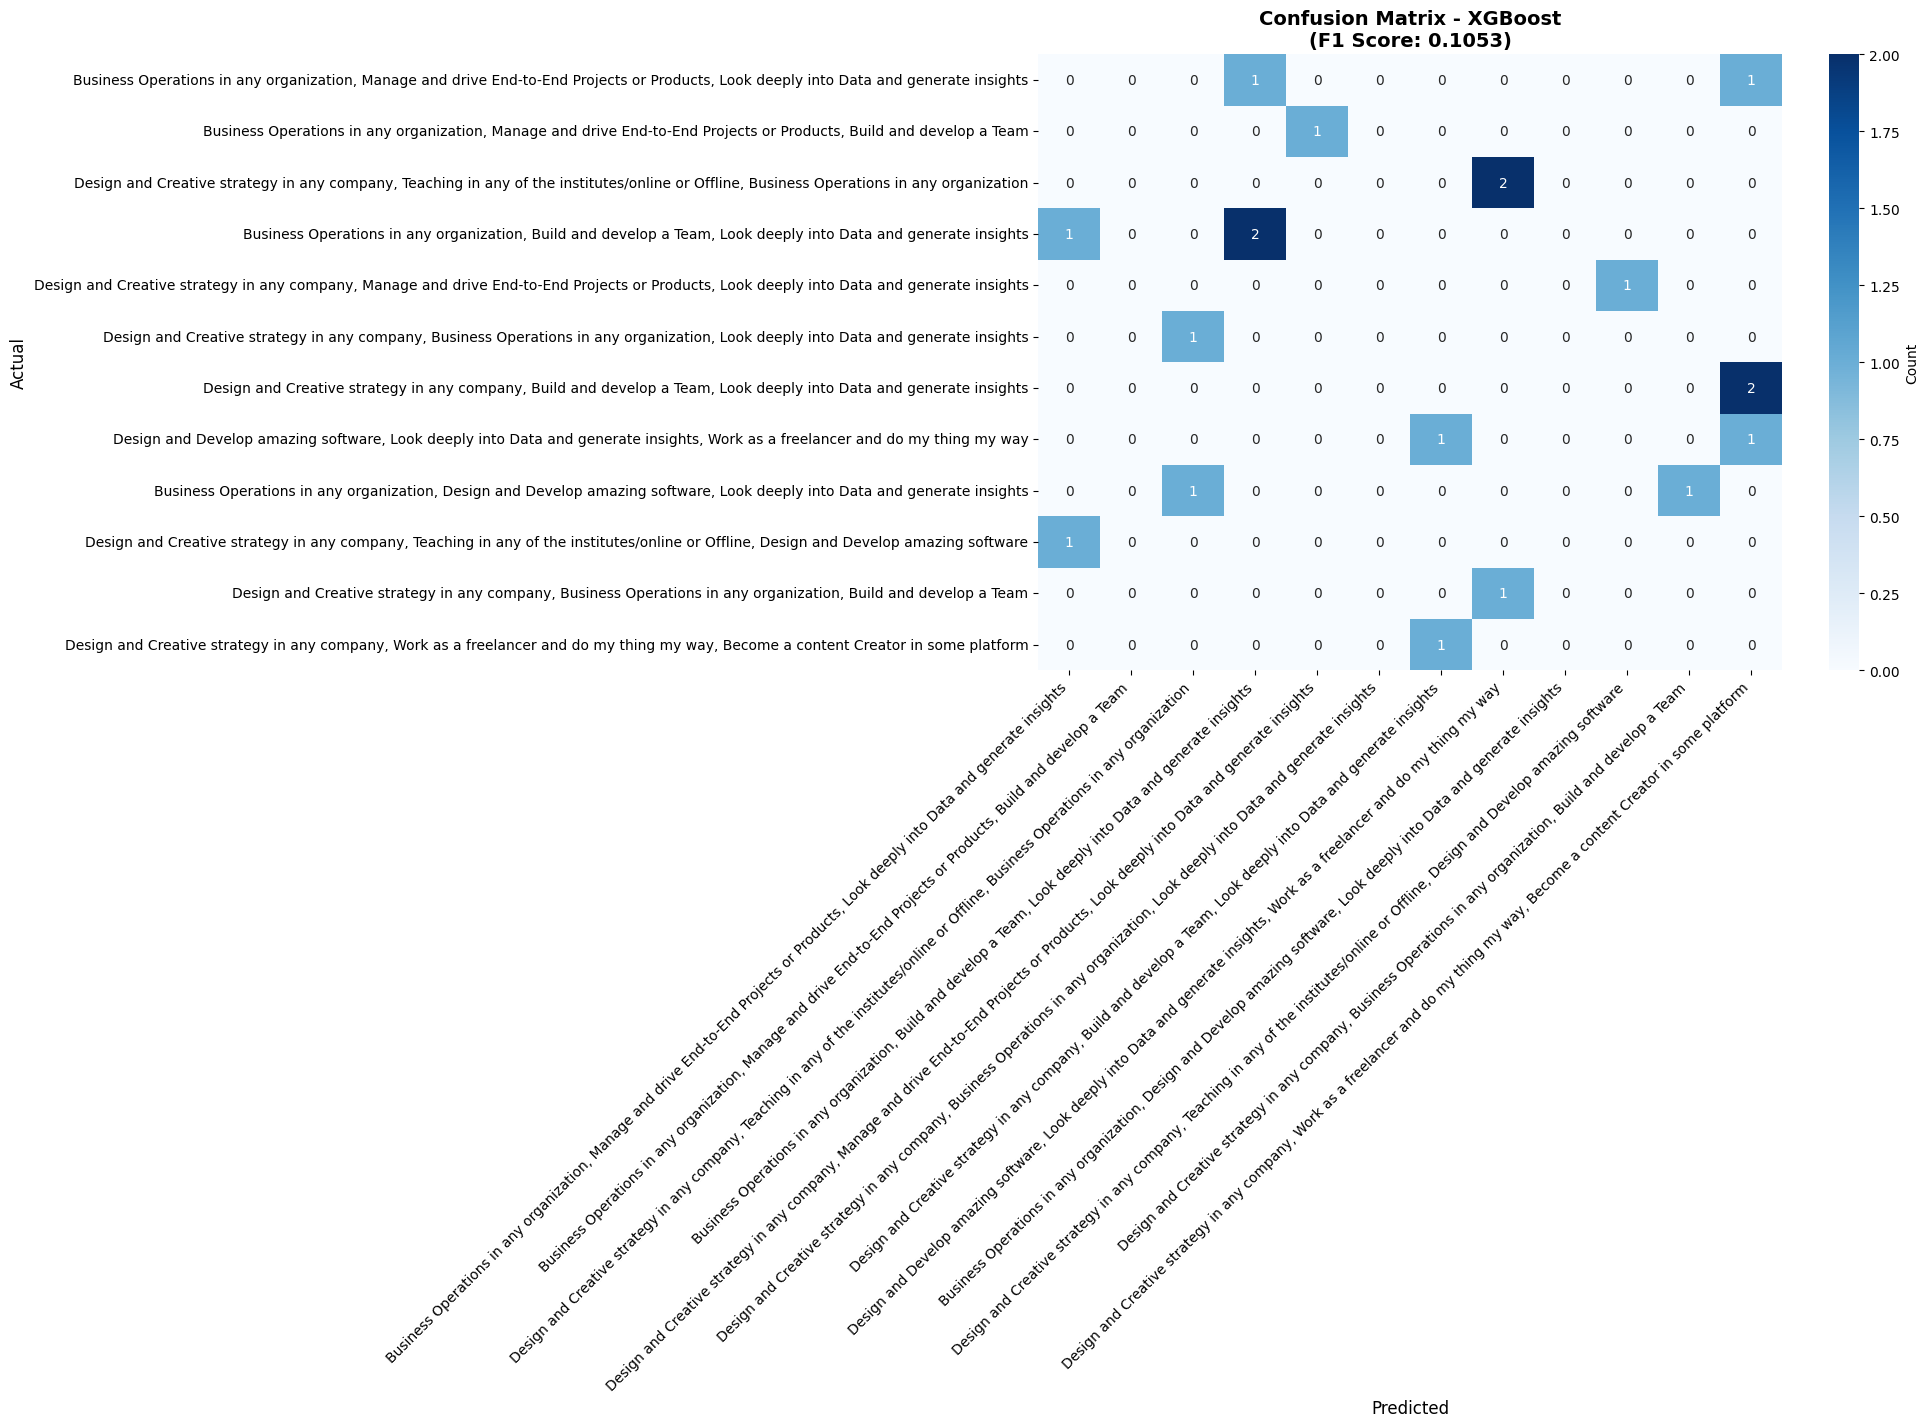

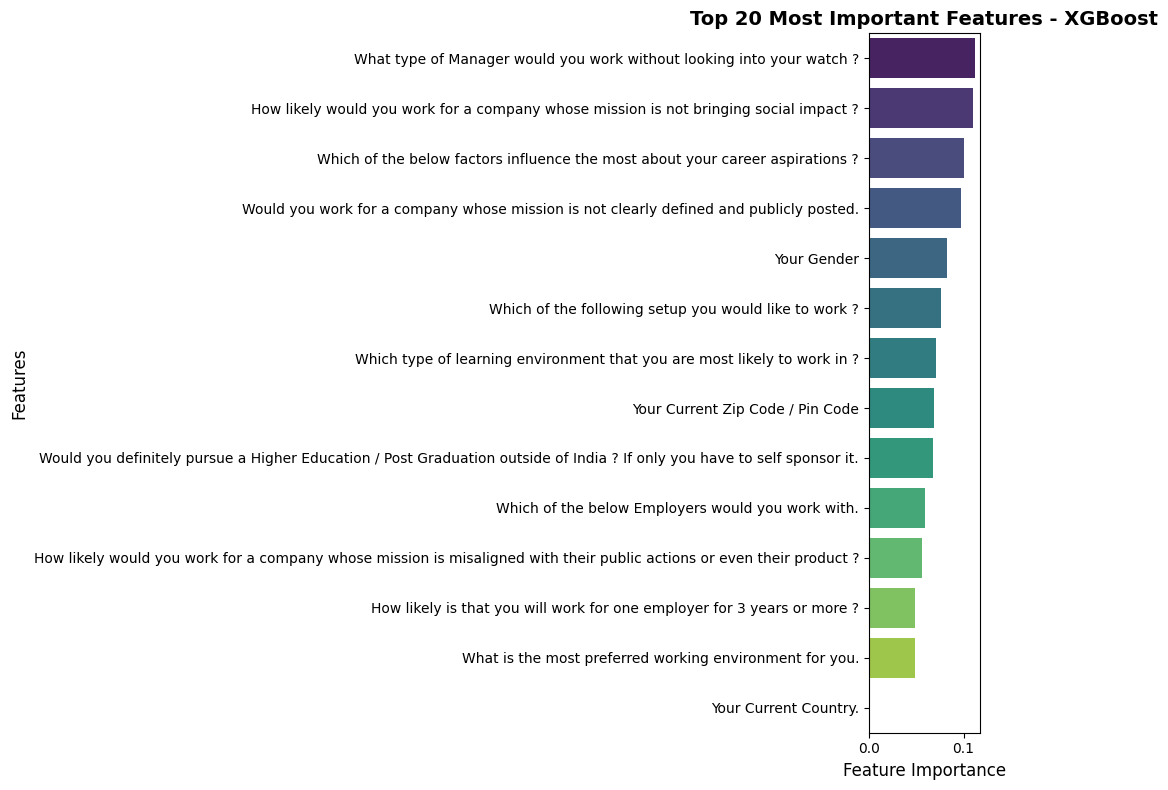


TOP 10 MOST IMPORTANT FEATURES
 1. What type of Manager would you work without looking into your watch ? 0.1118
 2. How likely would you work for a company whose mission is not bringing social impact ? 0.1096
 3. Which of the below factors influence the most about your career aspirations ? 0.1004
 4. Would you work for a company whose mission is not clearly defined and publicly posted. 0.0978
 5. Your Gender                              0.0831
 6. Which of the following setup you would like to work ? 0.0765
 7. Which type of learning environment that you are most likely to work in ? 0.0714
 8. Your Current Zip Code / Pin Code         0.0686
 9. Would you definitely pursue a Higher Education / Post Graduation outside of India ? If only you have to self sponsor it. 0.0676
10. Which of the below Employers would you work with. 0.0593

MODELING COMPLETE


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# Target column
TARGET = "Which of the below careers looks close to your Aspirational job ?"

# Drop missing targets
df_model = df.dropna(subset=[TARGET]).copy()

# Features and target separation
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

# Show original class distribution
print("=" * 60)
print("ORIGINAL CLASS DISTRIBUTION")
print("=" * 60)
print(y.value_counts().sort_values())
print(f"\nTotal classes: {y.nunique()}")
print(f"Total samples: {len(y)}")
print(f"Classes with only 1 sample: {(y.value_counts() == 1).sum()}")

# Encode all target classes
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

# Filter: drop classes with too few samples (min 5)
min_samples = 5
class_counts = pd.Series(y_encoded).value_counts()
valid_classes = class_counts[class_counts >= min_samples].index
mask = pd.Series(y_encoded).isin(valid_classes)
X_filtered = X[mask].copy()
y_filtered = y_encoded[mask]

print("\n" + "=" * 60)
print("FILTERED CLASS DISTRIBUTION")
print("=" * 60)
print(f"Classes kept: {len(valid_classes)} out of {len(class_counts)}")
print(f"Samples kept: {len(y_filtered)} out of {len(y)}")
print(f"Samples removed: {len(y) - len(y_filtered)}")

# Re-encode filtered targets contiguously (0,1,...,n-1)
le_target_filtered = LabelEncoder()
y_filtered = le_target_filtered.fit_transform(y_filtered)
filtered_class_names = [str(c) for c in le_target.classes_[valid_classes]]

# Encode categorical features
X_encoded = X_filtered.copy()
for col in X_encoded.columns:
    if X_encoded[col].dtype == "object":
        X_encoded[col] = X_encoded[col].fillna("<<MISSING>>")
        X_encoded[col] = LabelEncoder().fit_transform(X_encoded[col].astype(str))
    else:
        X_encoded[col] = X_encoded[col].fillna(X_encoded[col].median())

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_filtered, test_size=0.2, random_state=42, stratify=y_filtered
)
print(f"\nTraining samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# Define classifiers
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", random_state=42),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42)
}

# Train and evaluate
print("\n" + "=" * 60)
print("MODEL TRAINING & EVALUATION")
print("=" * 60)
results = {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    results[name] = {"Accuracy": acc, "F1": f1}
    print(f"\n===== {name} =====")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score (weighted): {f1:.4f}")
    print("\nClassification Report:")
    # Use descriptive class names for report
    print(classification_report(
        y_test, y_pred, target_names=filtered_class_names, zero_division=0
    ))

# Model comparison
results_df = pd.DataFrame(results).T.sort_values("F1", ascending=False)
print("\n" + "=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)
print(results_df)

# Confusion matrix of best model
best_model_name = results_df.index[0]
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(12, 8))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=filtered_class_names, yticklabels=filtered_class_names,
    cbar_kws={'label': 'Count'}
)
plt.title(f"Confusion Matrix - {best_model_name}\n(F1 Score: {results[best_model_name]['F1']:.4f})", 
          fontsize=14, fontweight='bold')
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Feature importance (if supported)
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(
        best_model.feature_importances_,
        index=X_encoded.columns
    ).sort_values(ascending=False).head(20)
    plt.figure(figsize=(10, 8))
    sns.barplot(x=importances.values, y=importances.index, palette="viridis")
    plt.title(f"Top 20 Most Important Features - {best_model_name}", 
              fontsize=14, fontweight='bold')
    plt.xlabel("Feature Importance", fontsize=12)
    plt.ylabel("Features", fontsize=12)
    plt.tight_layout()
    plt.show()
    print("\n" + "=" * 60)
    print("TOP 10 MOST IMPORTANT FEATURES")
    print("=" * 60)
    for i, (feat, imp) in enumerate(importances.head(10).items(), 1):
        print(f"{i:2d}. {feat:40s} {imp:.4f}")
elif hasattr(best_model, "coef_"):
    coef = np.abs(best_model.coef_).mean(axis=0)
    importances = pd.Series(coef, index=X_encoded.columns).sort_values(ascending=False).head(20)
    plt.figure(figsize=(10, 8))
    sns.barplot(x=importances.values, y=importances.index, palette="viridis")
    plt.title(f"Top 20 Most Important Features (Avg Abs Coefficients) - {best_model_name}", 
              fontsize=14, fontweight='bold')
    plt.xlabel("Average Absolute Coefficient", fontsize=12)
    plt.ylabel("Features", fontsize=12)
    plt.tight_layout()
    plt.show()

print("\n" + "=" * 60)
print("MODELING COMPLETE")
print("=" * 60)